In [20]:
import pandas as pd

# 1. 리더보드 데이터 하드코딩
data = [
    ["ResNet101V2", 0.94775, 0.947739, 224, "Optimized"],
    ["ResNet101", 0.94750, 0.947463, 224, "Optimized"],
    ["Xception", 0.94725, 0.947244, 299, "Optimized"],
    ["ResNet50V2", 0.94425, 0.944244, 224, "Optimized"],
    ["MobileNetV3Small", 0.94400, 0.943989, 224, "Optimized"],
    ["MobileNetV3Large", 0.94100, 0.940987, 224, "Optimized"],
    ["ResNet50", 0.93975, 0.939734, 224, "Optimized"],
    ["InceptionResNetV2", 0.93925, 0.939223, 299, "Optimized"],
    ["MobileNetV1", 0.93675, 0.936739, 224, "Optimized"],
    ["MobileNetV2", 0.93350, 0.933485, 224, "Optimized"],
    ["DenseNet121", 0.93325, 0.933227, 224, "Optimized"],
    ["InceptionV3", 0.93175, 0.931711, 299, "Optimized"],
    ["EfficientNetV2S", 0.93075, 0.930651, 384, "Optimized"],
    ["EfficientNetV2B0", 0.92625, 0.926145, 224, "Optimized"],
    ["EfficientNetV2B3", 0.92475, 0.924589, 300, "Optimized"],
    ["EfficientNetV2B1", 0.92425, 0.924153, 240, "Optimized"],
    ["EfficientNetV2B2", 0.92300, 0.922954, 260, "Optimized"],
    ["NASNetMobile", 0.90725, 0.907191, 224, "Optimized"],
    ["EfficientNetB3", 0.87200, 0.870330, 300, "Optimized"],
    ["EfficientNetB4", 0.85900, 0.856957, 380, "Optimized"],
    ["EfficientNetB0", 0.82050, 0.815287, 224, "Optimized"],
    ["EfficientNetB2", 0.81825, 0.814965, 260, "Optimized"],
    ["EfficientNetB1", 0.78400, 0.774232, 240, "Optimized"]
]

# 2. DataFrame 생성 및 인덱스(순위) 세팅
df = pd.DataFrame(data, columns=["Model", "Accuracy", "F1-Score", "Resolution", "Version"])
df.index = range(1, len(df) + 1)
df.index.name = "순위"

# 3. 요청하신 포맷 그대로 화면에 출력
print("======================================================================")
print("🏆 열화상 태양광 패널 모델 최종 리더보드 🏆")
print("======================================================================")
print(df.to_string())

🏆 열화상 태양광 패널 모델 최종 리더보드 🏆
                Model  Accuracy  F1-Score  Resolution    Version
순위                                                              
1         ResNet101V2   0.94775  0.947739         224  Optimized
2           ResNet101   0.94750  0.947463         224  Optimized
3            Xception   0.94725  0.947244         299  Optimized
4          ResNet50V2   0.94425  0.944244         224  Optimized
5    MobileNetV3Small   0.94400  0.943989         224  Optimized
6    MobileNetV3Large   0.94100  0.940987         224  Optimized
7            ResNet50   0.93975  0.939734         224  Optimized
8   InceptionResNetV2   0.93925  0.939223         299  Optimized
9         MobileNetV1   0.93675  0.936739         224  Optimized
10        MobileNetV2   0.93350  0.933485         224  Optimized
11        DenseNet121   0.93325  0.933227         224  Optimized
12        InceptionV3   0.93175  0.931711         299  Optimized
13    EfficientNetV2S   0.93075  0.930651         384  Optimized

🎨 Fixed Plot saved successfully: /Users/gyuminkang/Desktop/solar/output/ensemble_performance_trend_purple_fixed.png


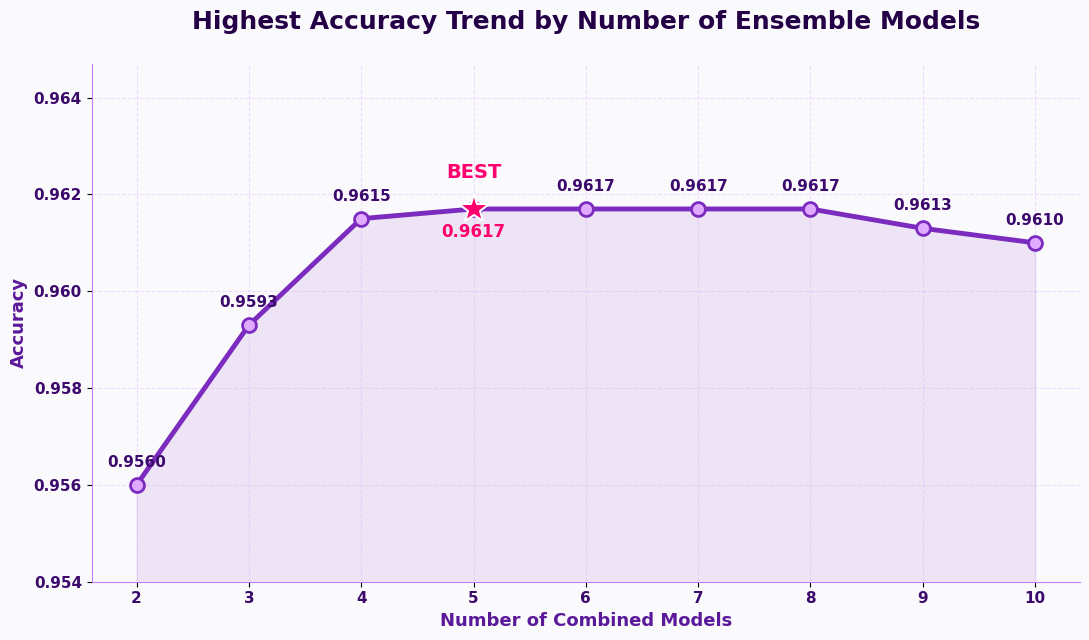

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

OUTPUT_PATH = "/Users/gyuminkang/Desktop/solar/output"

# 1. 채팅창에 남겨주신 기록을 바탕으로 데이터 수동 복구
recovered_data = [
    {"Num Models": 2, "Accuracy": 0.9560, "F1-Score": 0.9560, "Method": "Softmax Weighting", "Models": "Xception, MobileNetV3Large"},
    {"Num Models": 3, "Accuracy": 0.9593, "F1-Score": 0.9592, "Method": "Power Mean (p=0.5)", "Models": "ResNet101V2, ResNet101, MobileNetV3Large"},
    {"Num Models": 4, "Accuracy": 0.9615, "F1-Score": 0.9615, "Method": "Geometric Mean", "Models": "ResNet101V2, ResNet101, Xception, MobileNetV3Small"},
    {"Num Models": 5, "Accuracy": 0.9617, "F1-Score": 0.9617, "Method": "Geometric Mean", "Models": "ResNet101V2, ResNet101, Xception, MobileNetV3Small, DenseNet121"},
    {"Num Models": 6, "Accuracy": 0.9617, "F1-Score": 0.9617, "Method": "Geometric Mean", "Models": "ResNet101V2, ResNet101, Xception, MobileNetV3Small, MobileNetV3Large, DenseNet121"},
    {"Num Models": 7, "Accuracy": 0.9617, "F1-Score": 0.9617, "Method": "Power Mean (p=0.5)", "Models": "ResNet101V2, ResNet101, Xception, ResNet50V2, MobileNetV3Small, MobileNetV3Large, NASNetMobile"},
    {"Num Models": 8, "Accuracy": 0.9617, "F1-Score": 0.9617, "Method": "Geometric Mean", "Models": "ResNet101V2, ResNet101, Xception, MobileNetV3Small, MobileNetV3Large, MobileNetV1, DenseNet121, EfficientNetV2S"},
    {"Num Models": 9, "Accuracy": 0.9613, "F1-Score": 0.9612, "Method": "Geometric Mean", "Models": "ResNet101V2, ResNet101, Xception, MobileNetV3Small, MobileNetV3Large, MobileNetV1, DenseNet121, EfficientNetV2S, EfficientNetB3"},
    {"Num Models": 10, "Accuracy": 0.9610, "F1-Score": 0.9610, "Method": "Geometric Mean", "Models": "ResNet101V2, ResNet101, Xception, MobileNetV3Small, MobileNetV3Large, ResNet50, DenseNet121, InceptionV3, EfficientNetV2B1, EfficientNetB3"}
]

df_top = pd.DataFrame(recovered_data)

x = df_top["Num Models"]
y = df_top["Accuracy"]

# 2. 고급스러운 차트 스타일 설정
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 백그라운드 톤 설정
fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='#FAFAFC') 
ax.set_facecolor('#FAFAFC')

# 보라색 테마 컬러 코드
line_color = '#7B2CBF'    
marker_color = '#E0AAFF'  
text_color = '#3C096C'    
best_color = '#FF006E'    

# 3. 메인 라인 및 채우기
plt.plot(x, y, marker='o', linestyle='-', color=line_color, 
         linewidth=3.5, markersize=10, markerfacecolor=marker_color, 
         markeredgecolor=line_color, markeredgewidth=2, zorder=3)

# 곡선 아래 영역을 은은하게 칠해주기 
plt.fill_between(x, y, y.min() - 0.005, color=line_color, alpha=0.1, zorder=1)

# 4. 최고점(Best) 강조 표시
max_idx = y.idxmax()
plt.plot(x[max_idx], y[max_idx], marker='*', color=best_color, 
         markersize=22, markeredgecolor='white', markeredgewidth=1.5, zorder=4)

# 🏆 이모티콘 깨짐 방지를 위해 순수 텍스트 "BEST"로 수정
plt.annotate("BEST", (x[max_idx], y[max_idx]), textcoords="offset points", 
             xytext=(0,22), ha='center', color=best_color, fontweight='heavy', 
             fontsize=14, zorder=5)

# 5. 각 포인트별 정확도 텍스트
for i, txt in enumerate(y):
    if i != max_idx:
        plt.annotate(f"{txt:.4f}", (x.iloc[i], y.iloc[i]), 
                     textcoords="offset points", xytext=(0,13), ha='center', 
                     fontsize=11, fontweight='bold', color=text_color, zorder=5)
    else:
        plt.annotate(f"{txt:.4f}", (x.iloc[i], y.iloc[i]), 
                     textcoords="offset points", xytext=(0,-20), ha='center', 
                     fontsize=12, fontweight='bold', color=best_color, zorder=5)

# 6. 제목 및 라벨 꾸미기
plt.title("Highest Accuracy Trend by Number of Ensemble Models", 
          fontsize=18, fontweight='heavy', color='#240046', pad=25)
plt.xlabel("Number of Combined Models", fontsize=13, fontweight='bold', color='#5A189A')
plt.ylabel("Accuracy", fontsize=13, fontweight='bold', color='#5A189A')

plt.xticks(x, fontsize=11, color=text_color, fontweight='bold')
plt.yticks(fontsize=11, color=text_color, fontweight='bold')

# 7. 그리드 라인 및 테두리 정리
ax.grid(True, linestyle='--', color='#E0AAFF', alpha=0.4, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#C77DFF')
ax.spines['bottom'].set_color('#C77DFF')

y_min, y_max = y.min(), y.max()
plt.ylim(y_min - 0.002, y_max + 0.003)

# 8. 저장 및 출력
PLOT_PATH = os.path.join(OUTPUT_PATH, "ensemble_performance_trend_purple_fixed.png")
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, facecolor=fig.get_facecolor())
print(f"🎨 Fixed Plot saved successfully: {PLOT_PATH}")

plt.show()

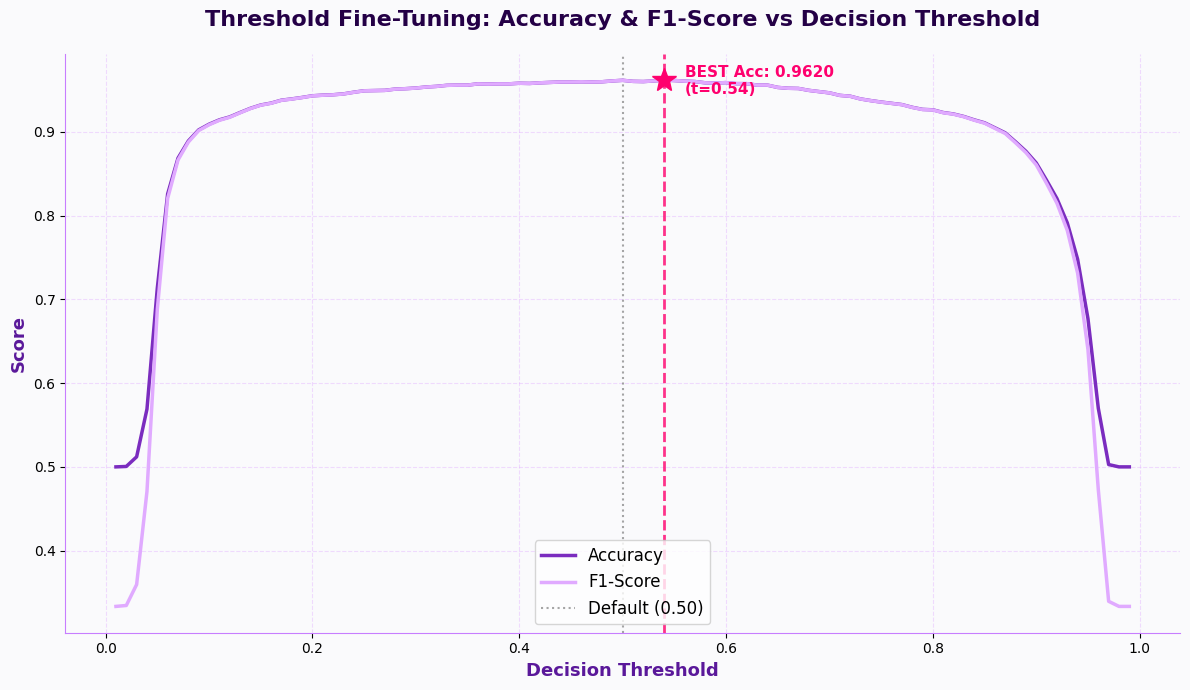

In [15]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

OUTPUT_PATH = "/Users/gyuminkang/Desktop/solar/output"

# 데이터 로드
with open(os.path.join(OUTPUT_PATH, 'ensemble_cache.pkl'), 'rb') as f:
    cache = pickle.load(f)

probs = cache['probs']
y_true = np.array(cache['y_true'])
EPS = 1e-7

# 최고 앙상블 확률 계산
best_models = ['ResNet101V2', 'ResNet101', 'Xception', 'MobileNetV3Small', 'DenseNet121']
S = np.array([probs[m] for m in best_models])
c = np.clip(S, EPS, 1 - EPS)
ensemble_prob = np.exp(np.mean(np.log(c), axis=0))

# 임계치(Threshold) 전수조사 연산
thresholds = np.arange(0.01, 1.00, 0.01)
results = []

for t in thresholds:
    y_pred = (ensemble_prob > t).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    results.append({
        "Threshold": round(t, 2),
        "Accuracy": acc,
        "F1-Score": f1
    })

df_results = pd.DataFrame(results)
best_acc_row = df_results.loc[df_results['Accuracy'].idxmax()]

# =========================================================
# 시각화 (사진만 깔끔하게 출력)
# =========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12, 7), facecolor='#FAFAFC')
ax.set_facecolor('#FAFAFC')

# 곡선 그리기
ax.plot(df_results['Threshold'], df_results['Accuracy'], color='#7B2CBF', linewidth=2.5, label='Accuracy', zorder=3)
ax.plot(df_results['Threshold'], df_results['F1-Score'], color='#E0AAFF', linewidth=2.5, label='F1-Score', zorder=3)

# 기준점(0.50)과 최고점 표시
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Default (0.50)')
ax.axvline(best_acc_row['Threshold'], color='#FF006E', linestyle='--', linewidth=2, alpha=0.8)
ax.plot(best_acc_row['Threshold'], best_acc_row['Accuracy'], marker='*', color='#FF006E', markersize=18, zorder=5)

ax.annotate(f"BEST Acc: {best_acc_row['Accuracy']:.4f}\n(t={best_acc_row['Threshold']:.2f})",
            (best_acc_row['Threshold'], best_acc_row['Accuracy']),
            textcoords="offset points", xytext=(15, -10), fontsize=11, fontweight='bold',
            color='#FF006E', zorder=5)

# 제목 및 스타일 세팅
ax.set_title("Threshold Fine-Tuning: Accuracy & F1-Score vs Decision Threshold",
             fontsize=16, fontweight='bold', color='#240046', pad=20)
ax.set_xlabel("Decision Threshold", fontsize=13, fontweight='bold', color='#5A189A')
ax.set_ylabel("Score", fontsize=13, fontweight='bold', color='#5A189A')
ax.legend(fontsize=12, loc='lower center')

ax.grid(True, linestyle='--', color='#E0AAFF', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#C77DFF')
ax.spines['bottom'].set_color('#C77DFF')

# 사진 저장 및 출력
plt.tight_layout()
PLOT_PATH = os.path.join(OUTPUT_PATH, "threshold_finetuning.png")
plt.savefig(PLOT_PATH, dpi=300, facecolor=fig.get_facecolor())
plt.show()

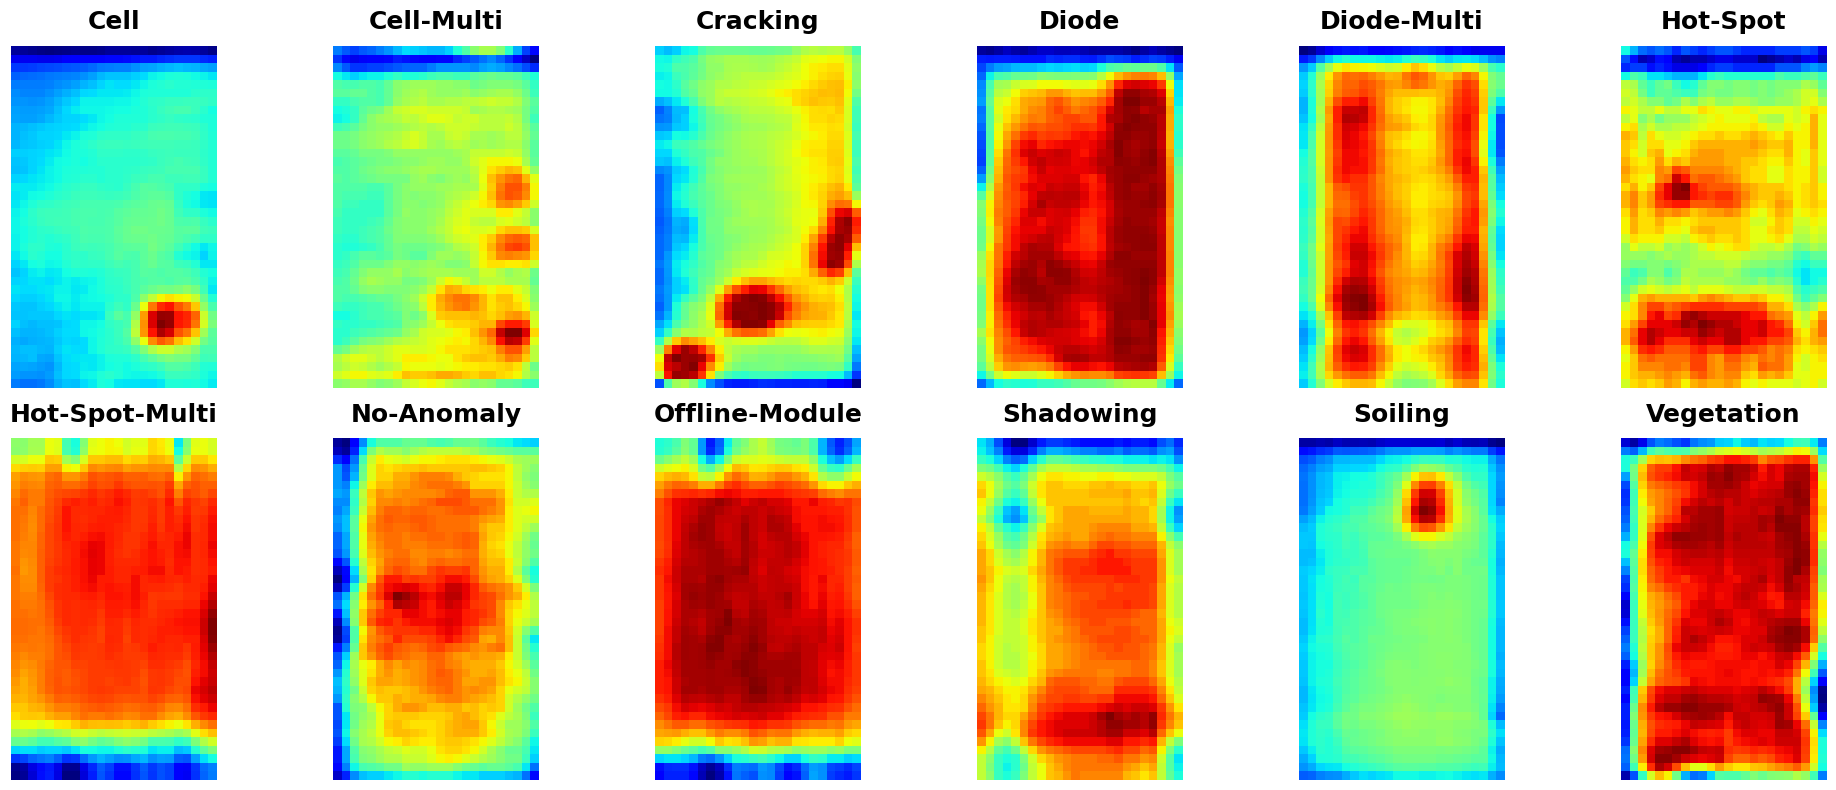

In [8]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import cv2

def plot_anomaly_samples(random_seed=None):
    # 1. 데이터가 있는 기본 경로 및 메타데이터 경로 설정
    BASE_DIR = "/Users/gyuminkang/Desktop/solar/InfraredSolarModules"
    JSON_PATH = os.path.join(BASE_DIR, "module_metadata.json")
    
    # 2. JSON 파일 읽어오기
    with open(JSON_PATH, 'r') as f:
        metadata = json.load(f)
        
    # 3. 읽어온 딕셔너리를 Pandas DataFrame으로 변환
    df = pd.DataFrame.from_dict(metadata, orient='index')
    
    # 4. 각 결함 클래스(anomaly_class)별로 이미지 1장씩 랜덤 추출 후 알파벳 순 정렬
    sample_df = df.groupby('anomaly_class').sample(n=1, random_state=random_seed)
    sample_df = sample_df.sort_values('anomaly_class')
    
    # 5. 전체 그림(Figure) 사이즈 설정
    plt.figure(figsize=(20, 8))
    
    # 6. 각 클래스별 이미지 시각화
    for i, (index, row) in enumerate(sample_df.iterrows(), start=1):
        # 전체 절대 경로로 조립 (ex: /Users/.../InfraredSolarModules/images/123.jpg)
        image_path = os.path.join(BASE_DIR, row['image_filepath'])
        class_name = row['anomaly_class']
        
        # OpenCV를 이용하여 흑백(Grayscale = 0)으로 이미지 로드
        img = cv2.imread(image_path, 0)
        
        # 2행 6열(총 12칸) 구조의 서브플롯 생성
        plt.subplot(2, 6, i)
        
        if img is not None:
            # 적외선(열화상) 특성을 잘 보여주는 'jet' 컬러맵 적용
            plt.imshow(img, cmap='jet')
        else:
            plt.text(0.5, 0.5, 'Image Load Failed', ha='center', va='center')
            
        # 제목 및 축 설정
        plt.title(class_name, fontsize=18, fontweight='bold', pad=12)
        plt.axis('off')
        
    # 간격 예쁘게 자동 조절
    plt.tight_layout()
    plt.show()

# 함수 실행 (random_seed를 바꾸거나 지우면 실행할 때마다 다른 이미지가 나옵니다)
plot_anomaly_samples(random_seed=42)

In [9]:
import os, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Mac OS 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = "/Users/gyuminkang/Desktop/solar/InfraredSolarModules"
OUTPUT_PATH = "/Users/gyuminkang/Desktop/solar/output"

# 1. 앙상블 캐시 데이터 로드
with open(os.path.join(OUTPUT_PATH, 'ensemble_cache.pkl'), 'rb') as f:
    cache = pickle.load(f)

probs = cache['probs']
y_true = np.array(cache['y_true'])
df_probs = pd.DataFrame(probs)

/var/folders/6n/mqz2xk3n1xd0qw_wj934y6br0000gn/T/ipykernel_77595/989972045.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_meta, y='anomaly_class',


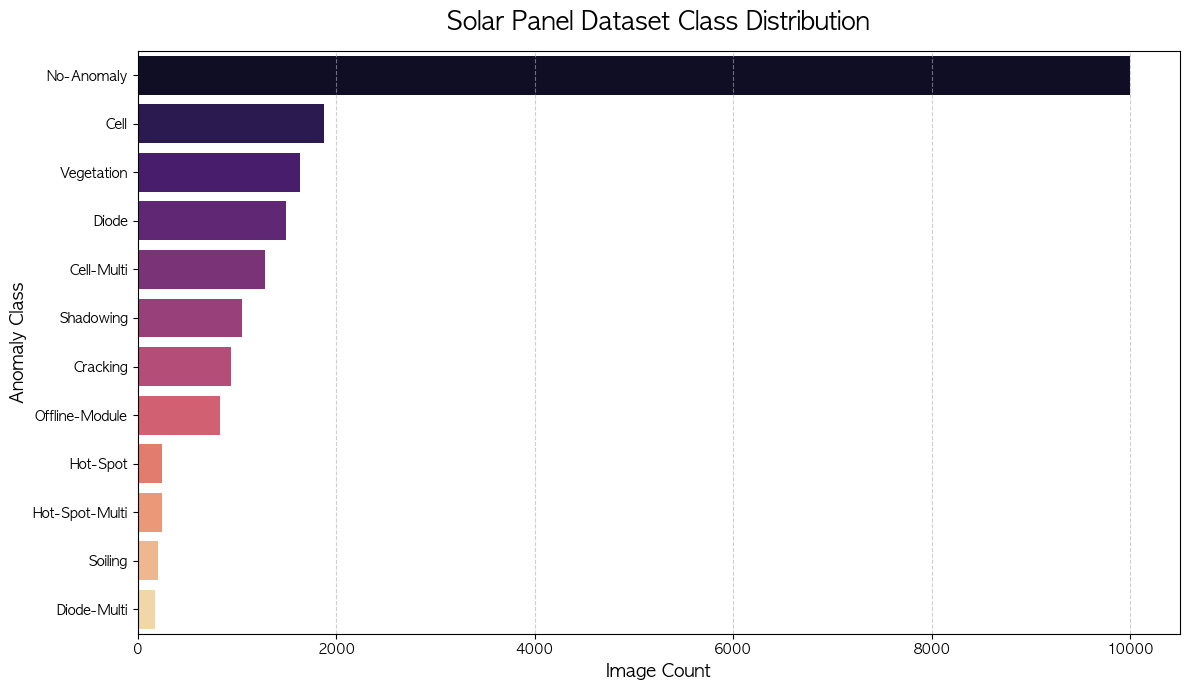

In [11]:
# Read JSON metadata
with open(os.path.join(BASE_DIR, "module_metadata.json"), 'r') as f:
    meta = json.load(f)
df_meta = pd.DataFrame.from_dict(meta, orient='index')

plt.figure(figsize=(12, 7))
sns.countplot(data=df_meta, y='anomaly_class', 
              order=df_meta['anomaly_class'].value_counts().index, 
              palette='magma')

plt.title("Solar Panel Dataset Class Distribution", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Image Count", fontsize=13)
plt.ylabel("Anomaly Class", fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Calculating t-SNE... (This may take 10~20 seconds)


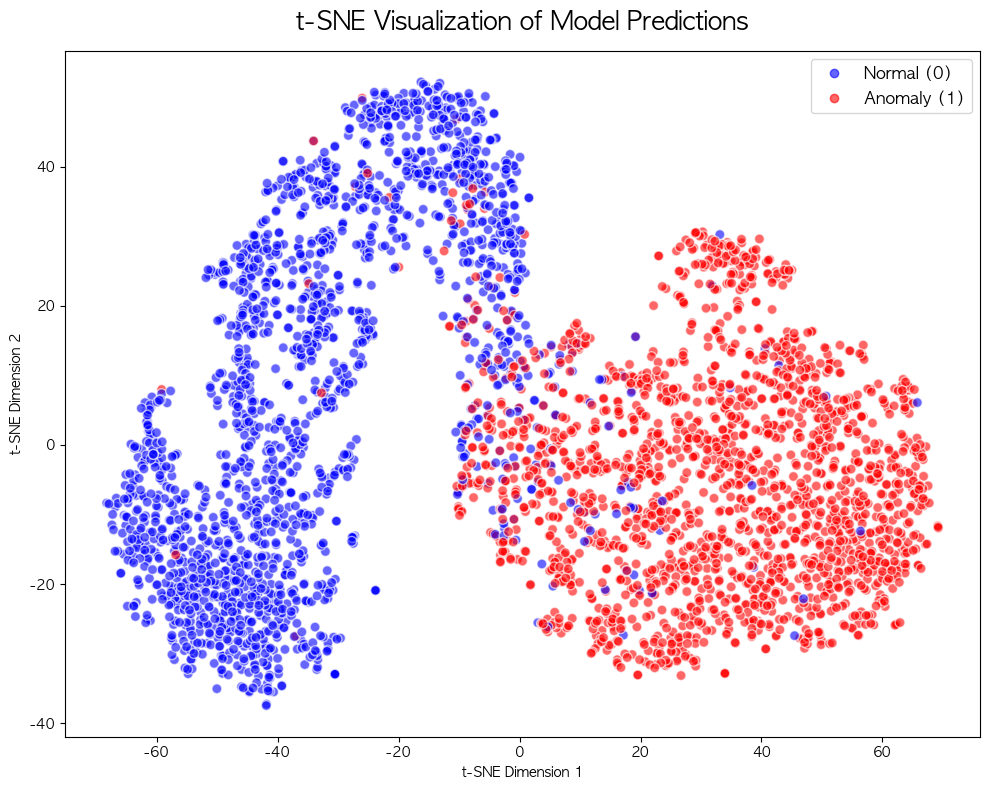

In [13]:
print("Calculating t-SNE... (This may take 10~20 seconds)")
# Use the 23 model probabilities (4000 x 23) as features for t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(df_probs.values)

plt.figure(figsize=(10, 8))

# Map 0 (Normal) to blue, 1 (Anomaly) to red
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap='bwr', alpha=0.6, edgecolors='w', s=50)

plt.title("t-SNE Visualization of Model Predictions", fontsize=18, fontweight='bold', pad=15)
plt.legend(handles=scatter.legend_elements()[0], labels=['Normal (0)', 'Anomaly (1)'], fontsize=12)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()

📊 혼동 행렬 이미지 저장 완료: /Users/gyuminkang/Desktop/solar/output/confusion_matrix_comparison.png


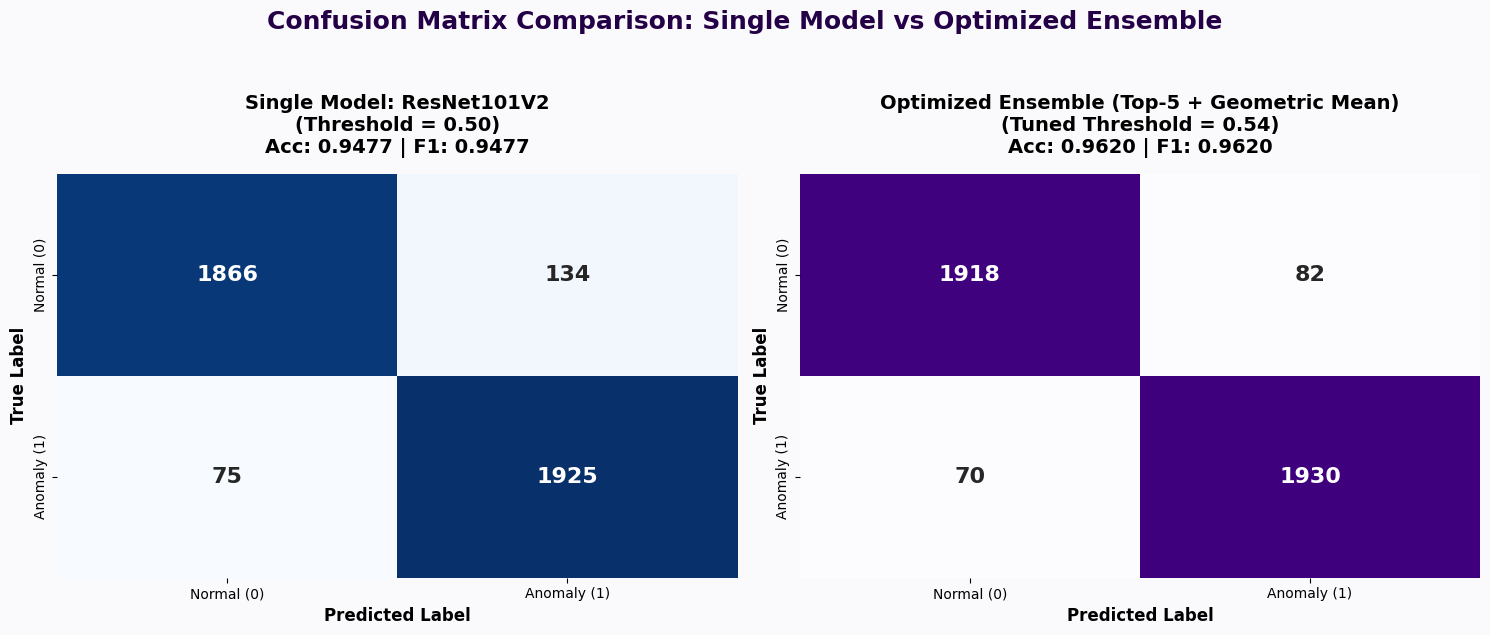

In [16]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

OUTPUT_PATH = "/Users/gyuminkang/Desktop/solar/output"

# 1. 캐시 데이터 로드 (가중치 로드 없이 1초 만에 예측 결과 불러오기)
with open(os.path.join(OUTPUT_PATH, 'ensemble_cache.pkl'), 'rb') as f:
    cache = pickle.load(f)

probs = cache['probs']
y_true = np.array(cache['y_true'])
EPS = 1e-7

# =========================================================
# 2. ResNet101V2 단일 모델 기본형 (Threshold = 0.5)
# =========================================================
resnet_prob = probs['ResNet101V2']
y_pred_single = (resnet_prob > 0.5).astype(int)

acc_single = accuracy_score(y_true, y_pred_single)
f1_single = f1_score(y_true, y_pred_single, average='weighted')
cm_single = confusion_matrix(y_true, y_pred_single)

# =========================================================
# 3. 베스트 5개 조합 (기하평균) + 임계치(Threshold) 튜닝
# =========================================================
best_models = ['ResNet101V2', 'ResNet101', 'Xception', 'MobileNetV3Small', 'DenseNet121']
S = np.array([probs[m] for m in best_models])
c = np.clip(S, EPS, 1 - EPS)
ensemble_prob = np.exp(np.mean(np.log(c), axis=0))

# 최적의 임계치 자동 탐색 (0.01 단위)
thresholds = np.arange(0.01, 1.00, 0.01)
best_t = 0.5
best_acc = 0

for t in thresholds:
    temp_pred = (ensemble_prob > t).astype(int)
    temp_acc = accuracy_score(y_true, temp_pred)
    if temp_acc > best_acc:
        best_acc = temp_acc
        best_t = t

# 탐색한 최적 임계치로 최종 예측
y_pred_ensemble = (ensemble_prob > best_t).astype(int)

acc_ensemble = accuracy_score(y_true, y_pred_ensemble)
f1_ensemble = f1_score(y_true, y_pred_ensemble, average='weighted')
cm_ensemble = confusion_matrix(y_true, y_pred_ensemble)

# =========================================================
# 4. 혼동 행렬(Confusion Matrix) 나란히 시각화
# =========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='#FAFAFC')

# 클래스 라벨 지정
labels = ['Normal (0)', 'Anomaly (1)']

# (1) 왼쪽: ResNet101V2 (단일 모델)
sns.heatmap(cm_single, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 16, "weight": "bold"}, cbar=False)
axes[0].set_title(f"Single Model: ResNet101V2\n(Threshold = 0.50)\nAcc: {acc_single:.4f} | F1: {f1_single:.4f}", 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')

# (2) 오른쪽: 베스트 5개 앙상블 + 최적 임계치
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 16, "weight": "bold"}, cbar=False)
axes[1].set_title(f"Optimized Ensemble (Top-5 + Geometric Mean)\n(Tuned Threshold = {best_t:.2f})\nAcc: {acc_ensemble:.4f} | F1: {f1_ensemble:.4f}", 
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')

# 전체 제목 설정
plt.suptitle("Confusion Matrix Comparison: Single Model vs Optimized Ensemble", 
             fontsize=18, fontweight='heavy', color='#240046', y=1.05)

# 사진 저장 및 출력
plt.tight_layout()
PLOT_PATH = os.path.join(OUTPUT_PATH, "confusion_matrix_comparison.png")
plt.savefig(PLOT_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"📊 혼동 행렬 이미지 저장 완료: {PLOT_PATH}")
plt.show()